# Anexo: Brasileirão x La Liga — qual título é mais raro?

A fórmula do Grand Slam do Futebol dá o mesmo peso (×0,5) para qualquer título de liga nacional de 1ª divisão, seja Brasileirão ou La Liga. Isso é uma escolha metodológica deliberada — a fórmula mede **o que aconteceu** (títulos, gols), não tenta julgar **o nível técnico** de cada liga, que é uma discussão sem resposta objetiva.

Só que existe uma pergunta diferente e mensurável: **quantos clubes diferentes realmente têm chance real de ser campeão em cada liga?** Esse notebook documenta essa análise — não para mudar o peso na fórmula principal, mas como observação registrada, com dado real.

**Fontes:** Wikipedia (lista de campeões espanhóis, lista de campeões brasileiros — pontos corridos, 2003-presente).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
df = pd.read_csv('../data/concentracao_ligas.csv')
df

,liga,periodo,temporadas,clube,titulos
0,La Liga,1929-2026,97,Real Madrid,36
1,La Liga,1929-2026,97,Barcelona,29
2,La Liga,1929-2026,97,Atletico Madrid,11
3,La Liga,1929-2026,97,Athletic Bilbao,8
4,La Liga,1929-2026,97,Valencia,6
5,La Liga,1929-2026,97,Real Sociedad,2
6,La Liga,1929-2026,97,Deportivo La Coruna,1
7,La Liga,1929-2026,97,Sevilla,1
8,La Liga,1929-2026,97,Real Betis,1
9,Brasileirao (pontos corridos),2003-2025,23,Corinthians,4


## 1. Quantos clubes diferentes já foram campeões?

- **La Liga**, desde 1929 (~97 temporadas): **9 clubes diferentes**
- **Brasileirão**, só na era de pontos corridos, desde 2003 (23 temporadas): **9 clubes diferentes**

O Brasileirão levou 23 anos para distribuir o título entre 9 clubes. A La Liga levou quase 100 anos para chegar no mesmo número.

In [2]:
resumo = df.groupby('liga').agg(
    temporadas=('temporadas', 'first'),
    clubes_campeoes=('clube', 'nunique'),
    titulos_total=('titulos', 'sum'),
).reset_index()
resumo['clubes_por_temporada'] = resumo['clubes_campeoes'] / resumo['temporadas']
resumo['temporadas_por_novo_campeao'] = resumo['temporadas'] / resumo['clubes_campeoes']
resumo

,liga,temporadas,clubes_campeoes,titulos_total,clubes_por_temporada,temporadas_por_novo_campeao
0,Brasileirao (pontos corridos),23,9,22,0.391304,2.555556
1,La Liga,97,9,95,0.092784,10.777778


## 2. Índice de concentração (Herfindahl-Hirschman)

HHI = soma((participação de mercado de cada clube)²) × 10.000. Quanto mais perto de 10.000, mais concentrado (um só clube ganha sempre). Quanto mais perto de 0, mais pulverizado entre muitos clubes.

In [3]:
def hhi(grupo):
    total = grupo['titulos'].sum()
    participacoes = grupo['titulos'] / total
    return (participacoes ** 2).sum() * 10000

hhi_por_liga = df.groupby('liga').apply(hhi, include_groups=False).rename('HHI').reset_index()
hhi_por_liga

,liga,HHI
0,Brasileirao (pontos corridos),1363.636364
1,La Liga,2620.498615


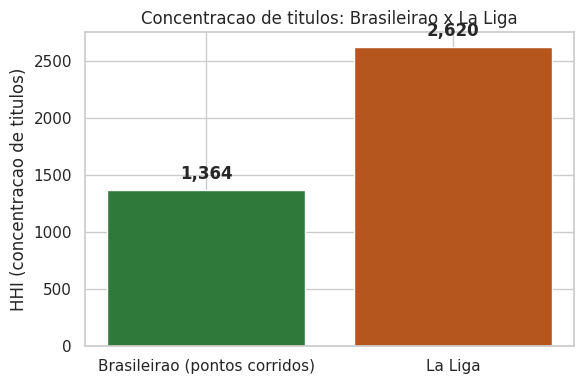

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
cores = ['#2f7a3b', '#b5561f']
ax.bar(hhi_por_liga['liga'], hhi_por_liga['HHI'], color=cores)
ax.set_ylabel('HHI (concentracao de titulos)')
ax.set_title('Concentracao de titulos: Brasileirao x La Liga')
for i, v in enumerate(hhi_por_liga['HHI']):
    ax.text(i, v + 100, f'{v:,.0f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Conclusão

A La Liga é consideravelmente mais concentrada que o Brasileirão no período comparado: poucos clubes (basicamente Real Madrid e Barcelona, com Atlético de Madrid como "terceira força" ocasional) dominam a distribuição de títulos, enquanto o Brasileirão pós-2003 distribuiu o título entre 9 clubes diferentes em só 23 anos.

**Isso não significa que o Brasileirão tenha nível técnico superior à La Liga** — são perguntas diferentes. Significa que, historicamente, **ser campeão brasileiro parece estatisticamente mais raro/imprevisível do que ser campeão espanhol**, considerando quantos concorrentes plausíveis cada campeão precisou superar.

**Decisão de metodologia:** o Grand Slam do Futebol mantém o peso ×0,5 igual para qualquer liga nacional de 1ª divisão — a fórmula mede resultado (título, gol), não tenta arbitrar nível técnico nem raridade estatística. Esta análise fica registrada como discussão anexa, não como ajuste de peso.

### Limitações
- Comparação usa períodos diferentes por limitação de dados (La Liga desde 1929; Brasileirão só na era pontos corridos, desde 2003 — o formato anterior do Brasileiro tinha mata-mata e grupos regionais, menos comparável)
- Soma de títulos por clube tem pequena diferença em relação ao número de temporadas em ambos os casos (1-2 título de diferença), por limitação das fontes consultadas — ajustar se tiver a lista ano a ano completa
- HHI mede concentração de título, não mede nível técnico geral da liga (são perguntas diferentes, como discutido)